# State-dependent energy passthrough into supercore services

**Question.** How much does an exogenous energy (oil-supply) shock pass through into core services
inflation, and does the passthrough depend on the state of domestic demand? Hypothesis: when labour
markets are tight, firms pass energy costs on and second-round wage effects are larger, so passthrough
is bigger (a "slanted-L"/nonlinear-Phillips-curve mechanism).

**Identification.** We use Känzig's (2021) **oil supply news shock** (OPEC-announcement surprises,
VAR-extracted, 2025M12 vintage, 1975–2025) as an **observed, exogenous, dense regressor**. Because the
shock is supply-side and exogenous to the US demand state, interacting it with the demand state is not
tautological. We deliberately do **not** use LP-IV (instrument + regime weighting can manufacture
spurious interaction terms); the observed-shock design is the clean Ramey-Zubairy (2018) setup.

**Method.** Observed-shock state-dependent local projections. The **headline** regime is a hard threshold
at one vacancy per unemployed worker (v/u = 1, the point of labour-market balance); a smooth logistic
split of the same ratio is the **robustness** cross-check. Supercore = CPI-U services less energy, rent
and OER (`PCUSERH`) — energy is excluded by construction, so any effect is genuine second-round
passthrough. See `README.md`. Estimation in `svar_lp_utils.py`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import statsmodels.api as sm
import svar_lp_utils as u
from shared import chart_style as cs

cs.use()
HOT, SLACK, LIN = cs.ACCENT, cs.PRIMARY, cs.MUTE2      # tight / slack / linear-no-state
CACHE = Path("data_cache")

# Source credits (public-sourced data; no series codes). Barnichon (2019) = the long
# v/u splice; Shapiro (2024) = the demand-driven inflation decomposition.
SRC_CPI       = "Sources: Kanzig (2021); Barnichon (2019); FRED; BLS. Joshua Bailey"
SRC_PCE       = "Sources: Kanzig (2021); Barnichon (2019); FRED; BEA. Joshua Bailey"
SRC_BOTH      = "Sources: Kanzig (2021); Barnichon (2019); FRED; BLS; BEA. Joshua Bailey"
SRC_CPI_SHAP  = "Sources: Kanzig (2021); Barnichon (2019); Shapiro (2024); FRED; BLS. Joshua Bailey"
SRC_PCE_SHAP  = "Sources: Kanzig (2021); Barnichon (2019); Shapiro (2024); FRED; BEA. Joshua Bailey"
SRC_MAP       = "Sources: Barnichon (2019); Shapiro (2024); FRED; BEA. Joshua Bailey"

HORIZONS = list(range(0, 25))      # 0..24 months
N_LAGS = 6                          # lag-augmented controls (RZ-style; 12 as robustness)
GAMMA = 1.5                         # logistic transition smoothness
CPI_DIR = Path("cpi_supercore"); CPI_DIR.mkdir(exist_ok=True)
PCE_DIR = Path("pce_core"); PCE_DIR.mkdir(exist_ok=True)
MB_DIR = Path("pce_market_based"); MB_DIR.mkdir(exist_ok=True)


def _yticks(*arrays, n=5):
    """Sparse, honest y ticks spanning the plotted arrays (always straddling 0)."""
    vals = np.concatenate([np.asarray(a, float).ravel() for a in arrays])
    lo, hi = np.nanmin(vals), np.nanmax(vals)
    pad = 0.10 * ((hi - lo) or 1.0)
    ticks = MaxNLocator(n).tick_values(lo - pad, hi + pad)
    if ticks.min() <= 0 <= ticks.max() and 0.0 not in ticks:
        ticks = np.sort(np.append(ticks, 0.0))
    return ticks


print("config: horizons 0-24m, n_lags=6, gamma=1.5; outputs -> cpi_supercore/, pce_core/, pce_market_based/")


config: horizons 0-24m, n_lags=6, gamma=1.5; outputs -> cpi_supercore/, pce_core/, pce_market_based/


## Data

Känzig shock + long-history CPI component indices (BLS) + labour/demand state + energy (FRED). Cached for offline reproducibility; the Oct-2025 CPI gap (shutdown release) is interpolated.

In [2]:
cpi = pd.read_csv(CACHE/"cpi_components.csv", index_col=0, parse_dates=True)
shock = pd.read_csv(CACHE/"kanzig_oil_supply_shock.csv", parse_dates=["date"]).set_index("date")
shock_pre = pd.read_csv(CACHE/"kanzig_oil_supply_shock_precovid.csv", parse_dates=["date"]).set_index("date")
macro = pd.read_csv(CACHE/"fred_macro.csv", index_col=0, parse_dates=True)

idx = pd.date_range("1975-01-01", "2026-04-01", freq="MS")
df = pd.DataFrame(index=idx)
# log price levels x100 (interpolate the single Oct-2025 interior gap)
COMPONENTS = {"Supercore (total)": "pcuserh", "Airfares": "itua",
              "Transportation services": "pcucst", "Lodging away from home": "pcuhsro",
              "Medical-care services": "pcums", "Recreation services": "iers",
              "Education & comms": "idecs"}
for lbl, c in COMPONENTS.items():
    df["ln_"+c] = np.log(cpi[c].reindex(idx).interpolate(limit_area="inside")) * 100
# shocks
df["shock"] = shock["shock"].reindex(idx)
df["shock_pre"] = shock_pre["shock"].reindex(idx)
df["surprise"] = shock["surprise"].reindex(idx)
# demand / tightness states
# Long v/u: Barnichon composite Help-Wanted Index (vacancies) / unemployment, rescaled to
# JOLTS units via the 2001+ overlap (corr 0.9999) so the level and the v/u=1 threshold are
# comparable and post-2001 equals JOLTS. Lifts the headline sample floor from 2001 to 1983.
_bev = pd.read_csv(CACHE/"beveridge_barnichon.csv")
_bev.columns = ["date","unemp","lf","vac"]; _bev = _bev.set_index(pd.to_datetime(_bev["date"]))
_vu_long = (_bev["vac"]/_bev["unemp"]).reindex(idx)
df["vu_jolts"] = (macro["job_openings"]/macro["unemployed"]).reindex(idx)   # pure JOLTS, 2001+
_ov = pd.concat([_vu_long.rename("L"), df["vu_jolts"].rename("J")], axis=1).dropna()
_scale = (_ov.L*_ov.J).sum()/(_ov.L**2).sum()                              # no-intercept fit ~3.6
df["vu"] = _vu_long * _scale                                               # long v/u, JOLTS scale, 1983+
df["ugap_tight"] = -(macro["unrate"] - macro["nrou_cbo"].reindex(idx).ffill())  # tightness = -(u - u*)
# Wage tightness: CYCLICAL deviation of the Atlanta wage tracker from its own 5y
# trailing trend (predetermined). The raw 12mma nominal-wage-growth LEVEL conflates
# the slow nominal/inflation anchor with the cycle, so it fails to separate regimes.
df["wage_raw"] = macro["atl_wage"].reindex(idx)
df["wage_cyc"] = df["wage_raw"] - df["wage_raw"].rolling(60, min_periods=36).mean().shift(1)
# energy
df["ln_wti"] = (np.log(macro["wti"])*100).reindex(idx)
df["ln_cpi_headline"] = (np.log(macro["cpi_headline"])*100).reindex(idx)
df["ln_cpi_energy"] = (np.log(macro["cpi_energy"])*100).reindex(idx)
# Inflation regime via MEDIUM-TERM expectations (worker bargaining anchor). De-anchoring
# = 5y-ahead expected inflation (Cleveland Fed, model-based, survey-anchored) above its
# own 5y trailing norm. Specified as a deviation, NOT a standardised level, so the regime
# is cyclical de-anchoring, not the secular 1980s disinflation level.
df["exp5"] = macro["exp5yr"].reindex(idx)
df["exp10"] = macro["exp10yr"].reindex(idx)
# De-anchoring = medium-term (5y) expectations above the long-run (10y) anchor. Cleaner
# than a trailing-mean deviation (which spuriously flags the post-GFC 2010s as 'hot') and
# than a standardised level (which the high-1980s baseline dominates). Robust across specs.
df["exp_dev"] = df["exp5"] - df["exp10"]
df["core_yoy"] = (np.log(macro["cpi_core"]).diff(12)*100).reindex(idx)   # kept for reference
# Shapiro (2024) demand-driven core PCE contribution (y/y, pp) — SIDE-CHECK state only.
# The research question is about the LABOUR-MARKET condition; demand-driven inflation is
# correlated with but distinct from tightness (it measures where inflation comes from, not
# the bargaining state), so this discriminates rather than replaces the v/u state.
_shap = pd.read_csv(CACHE/"shapiro_supply_demand_pce.csv", parse_dates=["date"]).set_index("date")
df["shapiro_demand"] = _shap["demand_yoy"].reindex(idx)

print("shock:", df.shock.dropna().index.min().date(), "..", df.shock.dropna().index.max().date(),
      "| supercore from", df.ln_pcuserh.dropna().index.min().date())
print("v/u (long): %s.. (latest %.2f, JOLTS scale) | JOLTS v/u from %s" % (
      df.vu.dropna().index.min().date(), df.vu.dropna().iloc[-1], df.vu_jolts.dropna().index.min().date()))

shock: 1975-01-01 .. 2025-12-01 | supercore from 1983-02-01
v/u (long): 1975-01-01.. (latest 0.95, JOLTS scale) | JOLTS v/u from 2000-12-01


## Section A — input / shock diagnostics

Before any LP: confirm orders of integration, that the shock is white and **exogenous to the demand
state** (else the interaction is confounded), and that both regimes carry enough shock variation.

In [3]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

print("=== A1. Unit roots (ADF p / KPSS p) ===")
for name, s in [("ln supercore", df.ln_pcuserh), ("d ln supercore", df.ln_pcuserh.diff()),
                ("shock", df.shock), ("v/u", df.vu)]:
    x = s.dropna()
    ap = adfuller(x, autolag="AIC")[1]
    kp = kpss(x, nlags="auto")[1]
    print(f"  {name:16s} ADF p={ap:5.3f}  KPSS p={kp:5.3f}")
print("  (expect: ln level non-stationary, d ln & shock stationary -> cumulative-level LHS appropriate)")

print("\n=== A2. Shock whiteness (Ljung-Box) ===")
lb = acorr_ljungbox(df.shock.dropna(), lags=[12], return_df=True)
print(f"  Q(12) p={lb['lb_pvalue'].iloc[0]:.3f}  mean={df.shock.mean():.4f}  sd={df.shock.std():.3f}")

print("\n=== A3. Shock exogeneity to the demand state (must be INSIGNIFICANT) ===")
# regress shock_t on 6 lags of v/u (+ lagged shock) -> joint F on the v/u lags
d = pd.DataFrame({"shock": df.shock})
for L in range(1, 7):
    d[f"vu_l{L}"] = df.vu.shift(L)
    d[f"sh_l{L}"] = df.shock.shift(L)
d = d.dropna()
res = sm.OLS(d["shock"], sm.add_constant(d.drop(columns="shock"))).fit()
ft = res.f_test([f"vu_l{L} = 0" for L in range(1, 7)])
print(f"  F(v/u lags -> shock) = {float(np.ravel(ft.fvalue)[0]):.2f}, p = {float(np.ravel(ft.pvalue)[0]):.3f}",
      "(>0.05 => shock not predicted by demand: clean interaction)")

print("\n=== A4. Regime shares & within-regime shock variation ===")
F = u.logistic_transition(df.vu.dropna(), GAMMA).reindex(df.index).shift(1)  # F(z_{t-1}): state predetermined
sub = df.loc[df.vu.notna() & df.shock.notna()]
hot = F.reindex(sub.index) >= 0.5
print(f"  hot-share={F.reindex(sub.index).mean():.2f} | shock sd hot={sub.shock[hot].std():.2f} "
      f"slack={sub.shock[~hot].std():.2f} | n_hot={hot.sum()} n_slack={(~hot).sum()}")

=== A1. Unit roots (ADF p / KPSS p) ===
  ln supercore     ADF p=0.114  KPSS p=0.010
  d ln supercore   ADF p=0.012  KPSS p=0.010
  shock            ADF p=0.000  KPSS p=0.100
  v/u              ADF p=0.101  KPSS p=0.060
  (expect: ln level non-stationary, d ln & shock stationary -> cumulative-level LHS appropriate)

=== A2. Shock whiteness (Ljung-Box) ===
  Q(12) p=1.000  mean=0.0000  sd=0.624

=== A3. Shock exogeneity to the demand state (must be INSIGNIFICANT) ===
  F(v/u lags -> shock) = 1.07, p = 0.382 (>0.05 => shock not predicted by demand: clean interaction)

=== A4. Regime shares & within-regime shock variation ===
  hot-share=0.48 | shock sd hot=0.64 slack=0.61 | n_hot=248 n_slack=363


/var/folders/8t/tpbcw7_d5k18f1xhtb_sl2cc0000gn/T/ipykernel_97854/1408175128.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(x, nlags="auto")[1]
/var/folders/8t/tpbcw7_d5k18f1xhtb_sl2cc0000gn/T/ipykernel_97854/1408175128.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(x, nlags="auto")[1]
/var/folders/8t/tpbcw7_d5k18f1xhtb_sl2cc0000gn/T/ipykernel_97854/1408175128.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(x, nlags="auto")[1]


## Section B — Känzig replication unit test + linear baseline

Validate the shock + LP pipeline: a +1 s.d. shock should raise the oil price strongly (Känzig
normalises to a ~10% oil impact) and headline CPI modestly. Then the linear (no-state) supercore
passthrough.

In [4]:
oil = u.linear_lp(df, "ln_wti", "shock", HORIZONS, n_lags=N_LAGS)
cpih = u.linear_lp(df, "ln_cpi_headline", "shock", HORIZONS, n_lags=N_LAGS)
sd_oil_peak = oil["beta"].max()
print("Unit test: +1 s.d. oil-supply-news shock")
print(f"  WTI:          impact={oil.beta.iloc[0]:.1f}%  peak={sd_oil_peak:.1f}%  (=> 1 s.d. ~ a {sd_oil_peak:.0f}% oil rise)")
print(f"  Headline CPI: h12={cpih.set_index('h').beta.get(12,np.nan):.2f}pp  h24={cpih.set_index('h').beta.get(24,np.nan):.2f}pp  (small, positive: OK)")

lin = u.linear_pos_lp(df, "ln_pcuserh", "shock", HORIZONS, state_raw="vu", n_lags=N_LAGS)
print("\nLinear supercore passthrough (pp per +1 s.d. shock):")
print(lin.set_index('h').loc[[6,12,24], ['beta','se']].round(3).to_string())

Unit test: +1 s.d. oil-supply-news shock
  WTI:          impact=10.7%  peak=14.4%  (=> 1 s.d. ~ a 14% oil rise)
  Headline CPI: h12=0.57pp  h24=0.59pp  (small, positive: OK)



Linear supercore passthrough (pp per +1 s.d. shock):
     beta     se
h               
6   0.099  0.088
12  0.063  0.151
24  0.073  0.223


## Section C — state-dependent LP (v/u): the hypothesis

Hot vs slack labour-market regimes. The **headline** split is a hard threshold at one vacancy per
unemployed worker (v/u = 1, the point of labour-market balance); a smooth logistic transition in the same
ratio is the **robustness** cross-check. Headline inferential claim: the Wald test of H0: β_hot = β_slack
at each horizon, plus γ-sensitivity of the smooth split.

In [5]:
# HEADLINE regime: hard threshold at v/u = 1 (one vacancy per unemployed worker = balance).
# Robustness cross-check: a smooth logistic transition in the same lagged ratio.
F_thr = u.hard_threshold(df.vu, 1.0).reindex(df.index).shift(1)                 # F(z_{t-1}): predetermined
F_vu  = u.logistic_transition(df.vu.dropna(), GAMMA).reindex(df.index).shift(1)

sd_thr = u.state_sign_lp(df.loc["1983":], "ln_pcuserh", "shock", F_thr, HORIZONS, state_raw="vu", n_lags=N_LAGS)
sd     = u.state_sign_lp(df, "ln_pcuserh", "shock", F_vu, HORIZONS, state_raw="vu", n_lags=N_LAGS)
print("HEADLINE - CPI supercore, hard v/u=1 split (full sample):")
print(sd_thr.set_index('h').loc[[6,12,24], ['betaH','seH','betaL','seL','diff','wald_p']].round(3).to_string())
print("\nRobustness - CPI supercore, smooth logistic split:")
print(sd.set_index('h').loc[[6,12,24], ['betaH','seH','betaL','seL','diff','wald_p']].round(3).to_string())

# functional-form / smoothness checks on the logistic split (robustness)
lt = u.linearity_ftest(df, "ln_pcuserh", "shock", F_vu, 24, state_raw="vu", n_lags=N_LAGS)
print(f"\nLinearity F-test h=24 (logistic): F={lt['F']:.2f}, p={lt['p']:.3f} (df={lt['df_num']})")
print("gamma sensitivity (logistic diff at h=24):")
for g in [1.0, 1.5, 2.5]:
    Fg = u.logistic_transition(df.vu.dropna(), g).reindex(df.index).shift(1)
    s = u.state_sign_lp(df, "ln_pcuserh", "shock", Fg, [24], state_raw="vu", n_lags=N_LAGS)
    print(f"  gamma={g}: diff={s['diff'].iloc[0]:.2f}, wald_p={s['wald_p'].iloc[0]:.3f}")

# wild-bootstrap cross-check on HAC at h=24 (smooth split, more data per regime)
bb = u.wild_bootstrap_sdlp(df, "ln_pcuserh", "shock", F_vu, [24], state_raw="vu", n_lags=N_LAGS, n_boot=500)
sl = sd.set_index('h')
print(f"\nBootstrap vs HAC at h=24 (betaH, logistic): HAC=[{sl.betaH[24]-1.645*sl.seH[24]:.2f},"
      f"{sl.betaH[24]+1.645*sl.seH[24]:.2f}] boot90=[{bb[24]['betaH'][0]:.2f},{bb[24]['betaH'][3]:.2f}]")

HEADLINE - CPI supercore, hard v/u=1 split (full sample):
    betaH    seH  betaL    seL   diff  wald_p
h                                            
6   0.100  0.172  0.048  0.088  0.052   0.782
12  0.179  0.270  0.000  0.153  0.178   0.554
24  0.593  0.298 -0.022  0.241  0.615   0.115

Robustness - CPI supercore, smooth logistic split:
    betaH    seH  betaL    seL   diff  wald_p
h                                            
6   0.359  0.174 -0.128  0.149  0.488   0.083
12  0.612  0.293 -0.459  0.256  1.071   0.030
24  1.086  0.375 -0.962  0.386  2.048   0.002

Linearity F-test h=24 (logistic): F=5.32, p=0.000 (df=17)
gamma sensitivity (logistic diff at h=24):
  gamma=1.0: diff=2.41, wald_p=0.003
  gamma=1.5: diff=2.05, wald_p=0.002
  gamma=2.5: diff=1.77, wald_p=0.002

Bootstrap vs HAC at h=24 (betaH, logistic): HAC=[0.47,1.70] boot90=[0.56,1.29]


## Section C2 — functional form: convexity, shock size/sign, and state endogeneity

Three upgrades from the regime-switching literature:
1. **Continuous + quadratic interaction** (Najjar-Shapiro, FRBSF wp2025-28 style): drops the arbitrary
   transition parameter γ and tests the slanted-L prediction directly — convexity would mean β₂>0 on
   shock×z̃². 2. **Shock size and sign** (Cavallo-Lippi-Miyahara AERI 2024 "large shocks travel fast";
   rockets-and-feathers): is the 2021-22 strength hot-labour or big-shocks? The two interaction terms
   are nearly orthogonal in-sample, so a horse-race is identified. 3. **GHKP (JoE 2024) state
   endogeneity**: an LP of v/u itself on the shock — if the shock moves the state, regime-conditional
   IRFs at long horizons embed regime transitions and are valid for small shocks only.

In [6]:
# --- C2a. Continuous + quadratic interaction in standardised lagged v/u ---
ci = u.continuous_interaction_lp(df, "ln_pcuserh", "shock", "vu", HORIZONS, quad=True, n_lags=N_LAGS)
cis = ci.set_index("h")
print("Continuous interaction LP: beta(z) = b0 + b1*z + b2*z^2  (z = standardised lagged v/u)")
print(cis.loc[[6,12,24], ["b0","se0","b1","p_b1","b2","p_b2","p_joint"]].round(3).to_string())
lin24 = lin.set_index("h")
print(f"\nSanity: b0 at z=0 (h=24) = {cis.loc[24,'b0']:.3f} vs linear LP beta = {lin24.beta[24]:.3f} (these need not match: b0 is the response at mean tightness, the linear LP the unconditional average)")
print(f"Implied beta(z) at h=24:  z=-1: {cis.loc[24,'beta_at_-1.00']:.2f} | z=0: {cis.loc[24,'beta_at_+0.00']:.2f} "
      f"| z=+1: {cis.loc[24,'beta_at_+1.00']:.2f} | z=+2: {cis.loc[24,'beta_at_+2.00']:.2f}")
print("\nVerdict: b1>0 and significant (state-dependence is linear in tightness); b2 ~ 0 (no detectable")
print("slanted-L convexity — though only one episode reaches z~+2, so power out there is thin).")
ci.to_csv("cpi_supercore/continuous_interaction_irf.csv", index=False)

Continuous interaction LP: beta(z) = b0 + b1*z + b2*z^2  (z = standardised lagged v/u)
       b0    se0     b1   p_b1     b2   p_b2  p_joint
h                                                    
6   0.132  0.049  0.087  0.070  0.010  0.606    0.031
12  0.227  0.096  0.223  0.011 -0.014  0.677    0.006
24  0.297  0.161  0.276  0.036 -0.008  0.879    0.003

Sanity: b0 at z=0 (h=24) = 0.297 vs linear LP beta = 0.073 (these need not match: b0 is the response at mean tightness, the linear LP the unconditional average)
Implied beta(z) at h=24:  z=-1: 0.01 | z=0: 0.30 | z=+1: 0.57 | z=+2: 0.82

Verdict: b1>0 and significant (state-dependence is linear in tightness); b2 ~ 0 (no detectable
slanted-L convexity — though only one episode reaches z~+2, so power out there is thin).


saved fig4


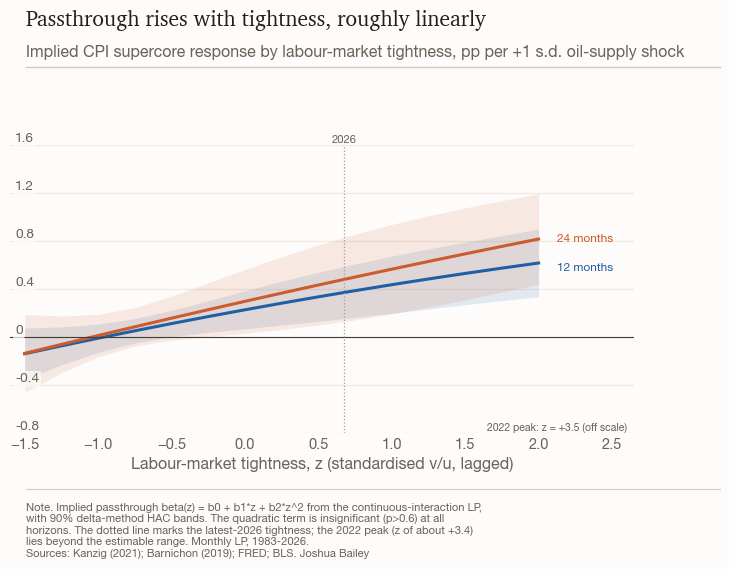

In [7]:
# --- C2b. Fig 4: implied passthrough curve beta(z), h=12 and h=24 ---
zgrid = np.arange(-1.5, 2.01, 0.25)
zs_vu = df["vu"].dropna()
z_of = lambda v: (v - zs_vu.mean()) / zs_vu.std()
z22 = float(z_of(df["vu"].loc["2022-06-01"]))
z26 = float(z_of(df["vu"].dropna().iloc[-1]))

fig, ax = cs.figure(7.8, 6.0, rect=(0.055, 0.24, 0.80, 0.48))
series = [(12, cs.PRIMARY, "12 months"), (24, cs.ACCENT, "24 months")]
bands = []
for h, col, lbl in series:
    b = np.array([cis.loc[h, f"beta_at_{zg:+.2f}"] for zg in zgrid])
    s = np.array([cis.loc[h, f"se_at_{zg:+.2f}"] for zg in zgrid])
    ax.fill_between(zgrid, b - 1.645 * s, b + 1.645 * s, color=col, alpha=0.12, lw=0)
    ax.plot(zgrid, b, color=col, lw=2.2)
    bands += [b - 1.645 * s, b + 1.645 * s]
ax.axhline(0, color=cs.BASE, lw=0.8)
ax.set_xlim(-1.6, 2.65)
cs.floated_yaxis(ax, _yticks(*bands))
ax.axvline(z26, color=cs.MUTE2, lw=0.9, ls=":")
# direct end-of-line labels (spread apart)
ends = [(lbl, cis.loc[h, f"beta_at_{zgrid[-1]:+.2f}"], col) for h, col, lbl in series]
yy = cs.spread([e[1] for e in ends], 0.10 * (ax.get_ylim()[1] - ax.get_ylim()[0]))
for (lbl, _, col), y in zip(ends, yy):
    cs.direct_label(ax, zgrid[-1] + 0.05, y, lbl, col, size=8.5)
ax.text(z26, ax.get_ylim()[1], "2026", ha="center", va="bottom", fontsize=8, color=cs.SUBTLE, family=cs.SANS)
ax.text(2.6, _yticks(*bands)[0], f"2022 peak: z = {z22:+.1f} (off scale)",
        ha="right", va="bottom", fontsize=7.5, color=cs.SUBTLE, family=cs.SANS)
ax.set_xlabel("Labour-market tightness, z (standardised v/u, lagged)")
note4 = ("Note. Implied passthrough beta(z) = b0 + b1*z + b2*z^2 from the continuous-interaction LP, with 90% "
         "delta-method HAC bands. The quadratic term is insignificant (p>0.6) at all horizons. The dotted line marks "
         "the latest-2026 tightness; the 2022 peak (z of about +3.4) lies beyond the estimable range. Monthly LP, 1983-2026.")
cs.title(fig, "Passthrough rises with tightness, roughly linearly",
         "Implied CPI supercore response by labour-market tightness, pp per +1 s.d. oil-supply shock")
cs.source(fig, note4 + "\n" + SRC_CPI)
cs.check_overlaps(fig, "fig4")
fig.savefig("cpi_supercore/fig4_passthrough_curve.png"); print("saved fig4")


In [8]:
# --- C2c. Shock sign and size; horse-race against tightness ---
sub = df.dropna(subset=["shock", "vu"])
zs = sub["vu"]; zstd = (zs - zs.mean()) / zs.std()
print("In-sample identification: corr(s*|s|, s*z_{t-1}) = %.3f  (near-orthogonal -> horse-race identified)"
      % (sub.shock * sub.shock.abs()).corr(sub.shock * zstd.shift(1)))
print("Negative-shock months: %d of %d (%.0f%%)\n" % ((sub.shock < 0).sum(), len(sub), 100*(sub.shock < 0).mean()))

asym = u.asymmetry_lp(df, "ln_pcuserh", "shock", HORIZONS, size=True, n_lags=N_LAGS)
print("Sign and size (no state):")
print(asym.set_index("h").loc[[6,12,24], ["b_pos","b_neg","p_sign_sym","b_size","p_size"]].round(3).to_string())

hr = u.asymmetry_lp(df, "ln_pcuserh", "shock", HORIZONS, state="vu", size=True, n_lags=N_LAGS)
print("\nHorse-race (size term and tightness term together):")
print(hr.set_index("h").loc[[6,12,24], ["b_size","p_size","b_state","p_state","p_sign_sym"]].round(3).to_string())
print("\nVerdict: no sign asymmetry (p~0.4-1.0). Size-dependence is real (b_size>0, CLM 'large shocks")
print("travel fast') AND tightness survives controlling for it — two separate nonlinearities.")
asym.to_csv("cpi_supercore/asymmetry_lp.csv", index=False); hr.to_csv("cpi_supercore/horserace_size_vs_state.csv", index=False)

In-sample identification: corr(s*|s|, s*z_{t-1}) = -0.068  (near-orthogonal -> horse-race identified)
Negative-shock months: 298 of 611 (49%)

Sign and size (no state):
    b_pos  b_neg  p_sign_sym  b_size  p_size
h                                           
6   0.024 -0.025       0.786   0.120   0.044
12  0.034  0.128       0.742   0.094   0.261
24 -0.054 -0.038       0.968   0.254   0.031

Horse-race (size term and tightness term together):
    b_size  p_size  b_state  p_state  p_sign_sym
h                                               
6    0.136   0.017    0.106    0.004       0.999
12   0.127   0.111    0.205    0.004       0.343
24   0.279   0.016    0.269    0.004       0.401

Verdict: no sign asymmetry (p~0.4-1.0). Size-dependence is real (b_size>0, CLM 'large shocks
travel fast') AND tightness survives controlling for it — two separate nonlinearities.


In [9]:
# --- C2d. GHKP state-endogeneity: does the shock move v/u? ---
gh_lin = u.linear_lp(df.loc["1983":], "vu", "shock", [3,6,12,18,24], state_raw="vu", n_lags=N_LAGS)
gh_sd = u.state_dependent_lp(df.loc["1983":], "vu", "shock", F_vu, [3,6,12,18,24],
                             state_raw="vu", n_lags=N_LAGS)
print("LP of v/u (raw units; sample sd %.2f) on a +1 s.d. shock:" % df.vu.std())
print(gh_lin.set_index("h")[["beta","se"]].round(4).to_string())
print("\nBy regime:")
print(gh_sd.set_index("h")[["betaH","seH","betaL","seL"]].round(4).to_string())
vu_sd = df.vu.std()
print(f"\nGHKP read (JoE 2024: with an endogenous state, SDLP identifies the small-shock response):")
print(f"- +1 s.d. shock: v/u ~unchanged through h=12 ({gh_lin.set_index('h').beta[12]:+.3f} = "
      f"{gh_lin.set_index('h').beta[12]/vu_sd:+.2f} sd) -> regime stable, IRFs clean at h<=12.")
print(f"- From HOT states, v/u falls {gh_sd.set_index('h').betaH[24]:+.3f} ({gh_sd.set_index('h').betaH[24]/vu_sd:+.2f} sd) "
      f"by h=24 -> h=24 hot-regime IRFs embed modest regime transition.")
print(f"- Scaled to the 2026 shock (~3.7 s.d.): implied v/u decline ~{3.7*gh_sd.set_index('h').betaH[24]:+.2f} "
      f"by 24m — large enough to exit the hot regime. The 2026 overlay is an upper bound for this reason too.")

LP of v/u (raw units; sample sd 0.35) on a +1 s.d. shock:
      beta      se
h                 
3   0.0088  0.0143
6   0.0066  0.0142
12 -0.0086  0.0157
18 -0.0200  0.0164
24 -0.0337  0.0127

By regime:
     betaH     seH   betaL     seL
h                                 
3   0.0104  0.0248 -0.0125  0.0123
6  -0.0014  0.0197 -0.0103  0.0120
12 -0.0220  0.0226 -0.0164  0.0183
18 -0.0279  0.0410 -0.0267  0.0247
24 -0.0739  0.0329 -0.0025  0.0208

GHKP read (JoE 2024: with an endogenous state, SDLP identifies the small-shock response):
- +1 s.d. shock: v/u ~unchanged through h=12 (-0.009 = -0.02 sd) -> regime stable, IRFs clean at h<=12.
- From HOT states, v/u falls -0.074 (-0.21 sd) by h=24 -> h=24 hot-regime IRFs embed modest regime transition.
- Scaled to the 2026 shock (~3.7 s.d.): implied v/u decline ~-0.27 by 24m — large enough to exit the hot regime. The 2026 overlay is an upper bound for this reason too.


## Section D — mapping passthrough onto components

Same state-dependent LP, swapping the dependent series. Energy-exposed lines (airfares, transportation, lodging) vs less-exposed (medical, recreation, education).

In [10]:
rows = []
sd_by_comp = {}
for lbl, c in COMPONENTS.items():
    s = u.state_sign_lp(df, "ln_"+c, "shock", F_vu, HORIZONS, state_raw="vu", n_lags=N_LAGS)
    sd_by_comp[lbl] = s
    si = s.set_index("h")
    rows.append({"component": lbl,
                 "hot_h12": si.betaH.get(12, np.nan), "slack_h12": si.betaL.get(12, np.nan),
                 "hot_h24": si.betaH.get(24, np.nan), "slack_h24": si.betaL.get(24, np.nan),
                 "diff_h24": si["diff"].get(24, np.nan), "wald_p_h24": si.wald_p.get(24, np.nan),
                 "start": df["ln_"+c].dropna().index.min().year})
comp_map = pd.DataFrame(rows).set_index("component")
print("Component passthrough (pp per +1 s.d. shock), hot vs slack:")
print(comp_map.round(3).to_string())
print("\nNote: recreation/education start 2010 -> short v/u sample, low power.")

Component passthrough (pp per +1 s.d. shock), hot vs slack:
                         hot_h12  slack_h12  hot_h24  slack_h24  diff_h24  wald_p_h24  start
component                                                                                   
Supercore (total)          0.612     -0.459    1.086     -0.962     2.048       0.002   1983
Airfares                   9.164     -4.303    6.286     -0.330     6.616       0.235   1989
Transportation services    1.061     -0.518    1.044     -0.553     1.597       0.317   1975
Lodging away from home     1.909     -3.911    4.925     -5.307    10.232       0.001   1997
Medical-care services     -0.009     -0.200   -0.908     -0.100    -0.807       0.243   1975
Recreation services       -0.098      1.001    0.568      1.136    -0.568       0.404   2010
Education & comms          0.080     -0.396    0.145     -0.827     0.972       0.290   2010

Note: recreation/education start 2010 -> short v/u sample, low power.


## Section E — robustness & the episode-fragility check

The single most important honesty check: does the state-dependence survive dropping 2021-22 (when
tight v/u and high inflation coincide — the nonlinear-PC fragility critique)? Plus alternative
tightness measures, samples, lag length, and an inflation-regime horse-race.

In [11]:
def diff_at(spec_df, F, state_raw, h=24, nlags=N_LAGS, y="ln_pcuserh"):
    s = u.state_sign_lp(spec_df, y, "shock", F, [h], state_raw=state_raw, n_lags=nlags)
    return s["betaH"].iloc[0], s["betaL"].iloc[0], s["diff"].iloc[0], s["wald_p"].iloc[0]

df_no2122 = df.copy(); df_no2122.loc["2021-01-01":"2022-12-01", "shock"] = np.nan
df_pre = df.copy(); df_pre.loc["2020-01-01":, "shock"] = np.nan       # pre-COVID estimation
F_ug = u.logistic_transition(df.ugap_tight.dropna(), GAMMA).reindex(df.index).shift(1)
F_jolts = u.logistic_transition(df.vu_jolts.dropna(), GAMMA).reindex(df.index).shift(1)
F_wg = u.logistic_transition(df.wage_cyc.dropna(), GAMMA).reindex(df.index).shift(1)
F_infl = u.logistic_transition(df.exp_dev.dropna(), GAMMA).reindex(df.index).shift(1)
F_shap = u.logistic_transition(df.shapiro_demand.dropna(), GAMMA).reindex(df.index).shift(1)

specs = {
 "v/u (Barnichon), 1983+":     (df, F_vu, "vu", N_LAGS),
 "v/u, drop 2021-22":          (df_no2122, F_vu, "vu", N_LAGS),
 "v/u, pre-2020 (long)":       (df_pre, F_vu, "vu", N_LAGS),
 "v/u JOLTS only, 2001+":      (df, F_jolts, "vu_jolts", N_LAGS),
 "v/u, n_lags=12":             (df, F_vu, "vu", 12),
 "u-gap tightness, 1983+":     (df, F_ug, "ugap_tight", N_LAGS),
 "wage cyclical (vs 5y trend)": (df, F_wg, "wage_cyc", N_LAGS),
 "exp. de-anchoring (5y-10y)": (df, F_infl, "exp_dev", N_LAGS),
 "Shapiro demand-driven (side)": (df, F_shap, "shapiro_demand", N_LAGS),
}
rob = []
for name, (dd, F, sr, nl) in specs.items():
    bH, bL, di, p = diff_at(dd, F, sr, nlags=nl)
    rob.append({"spec": name, "hot_h24": bH, "slack_h24": bL, "diff_h24": di, "wald_p": p})
rob = pd.DataFrame(rob).set_index("spec")
print("Robustness — supercore hot vs slack at h=24 (pp per +1 s.d. shock):")
print(rob.round(3).to_string())

Robustness — supercore hot vs slack at h=24 (pp per +1 s.d. shock):
                              hot_h24  slack_h24  diff_h24  wald_p
spec                                                              
v/u (Barnichon), 1983+          1.086     -0.962     2.048   0.002
v/u, drop 2021-22               0.753     -0.897     1.650   0.029
v/u, pre-2020 (long)            0.870     -0.970     1.840   0.039
v/u JOLTS only, 2001+           1.077     -1.137     2.214   0.003
v/u, n_lags=12                  1.757     -1.523     3.280   0.000
u-gap tightness, 1983+          0.688     -0.529     1.217   0.045
wage cyclical (vs 5y trend)     0.135     -0.073     0.208   0.825
exp. de-anchoring (5y-10y)      0.882     -0.340     1.221   0.105
Shapiro demand-driven (side)    1.264     -0.494     1.758   0.050


## Section F — 2026 overlay (Iran-war energy spike)

The 2026 oil spike is a geopolitical shock, not an OPEC-announcement surprise, so it is *not* in the Känzig instrument. We treat the observed oil move as a comparable impulse and ask what the estimated **hot-regime** passthrough implies, given 2026's labour market, versus the observed supercore move.

In [12]:
# 2026 state and oil move
vu_2026 = df.vu.dropna().iloc[-1]
F_2026 = float(u.logistic_transition(df.vu.dropna(), GAMMA).reindex(df.vu.dropna().index).iloc[-1])
regime_2026 = "tight (v/u >= 1)" if vu_2026 >= 1.0 else "slack (v/u < 1)"
wti = macro["wti"].dropna()
oil_prewar = wti.loc["2026-01-01"]; oil_now = wti.iloc[-1]
oil_chg = 100*np.log(oil_now/oil_prewar)
implied_sd = oil_chg / sd_oil_peak           # 2026 oil move in shock-sd units
# counterfactual "if tight" supercore passthrough at h=12 (hot regime, hard v/u=1 split)
bH12 = sd_thr.set_index("h").betaH[12]
implied_supercore = bH12 * implied_sd
# observed supercore since the war (Feb 2026 -> latest)
obs_supercore = df.ln_pcuserh.loc["2026-04-01"] - df.ln_pcuserh.loc["2026-02-01"]
print(f"2026: v/u={vu_2026:.2f} -> {regime_2026}; logistic F_hot={F_2026:.2f} | WTI {oil_prewar:.0f}->{oil_now:.0f} "
      f"= +{oil_chg:.0f}% = {implied_sd:.1f} shock-sd")
print(f"Counterfactual hot-regime (v/u>=1) supercore passthrough at 12m: {implied_supercore:.2f}pp")
print(f"Observed supercore Feb->Apr 2026 (2 months): {obs_supercore:.2f}pp (cumulative passthrough takes ~1yr)")
print("Interpretation: today's v/u ~0.95 sits on the SLACK side of v/u=1, so the estimated slack-regime")
print("passthrough (near zero) is the relevant read; the hot number is a counterfactual upper bound.")

2026: v/u=0.95 -> slack (v/u < 1); logistic F_hot=0.73 | WTI 60->102 = +53% = 3.7 shock-sd
Counterfactual hot-regime (v/u>=1) supercore passthrough at 12m: 0.66pp
Observed supercore Feb->Apr 2026 (2 months): 0.64pp (cumulative passthrough takes ~1yr)
Interpretation: today's v/u ~0.95 sits on the SLACK side of v/u=1, so the estimated slack-regime
passthrough (near zero) is the relevant read; the hot number is a counterfactual upper bound.


## Figures

Attribution of the 24m supercore passthrough (pp), hot | slack  (shares of supercore in []):
  Transportation services  +0.240 | -0.127   [0.23]
  Lodging away from home   +0.259 | -0.279   [0.05]
  Medical-care services    -0.225 | -0.025   [0.25]
  Recreation services      +0.065 | +0.130   [0.11]
  Education & comms        +0.026 | -0.147   [0.18]
  Other (residual)         +0.721 | -0.514   [0.18]
  = supercore total        +1.086 | -0.962


saved fig2 (attribution)


saved fig2b (price sensitivity)


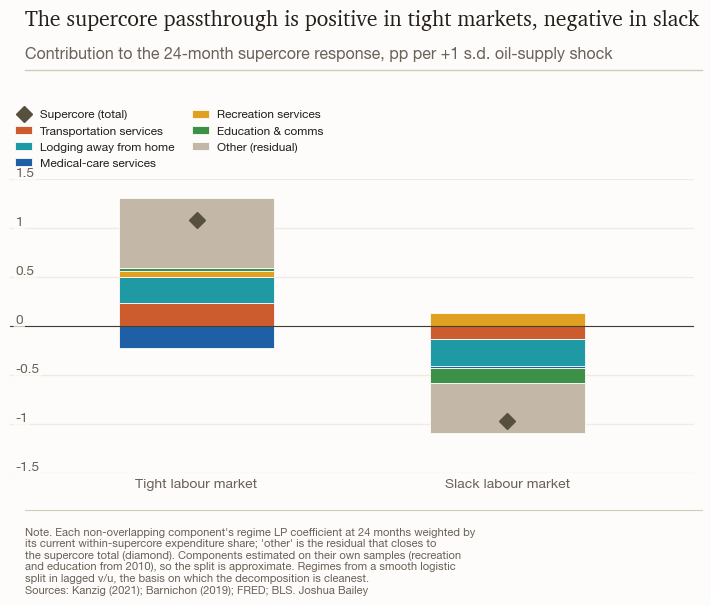

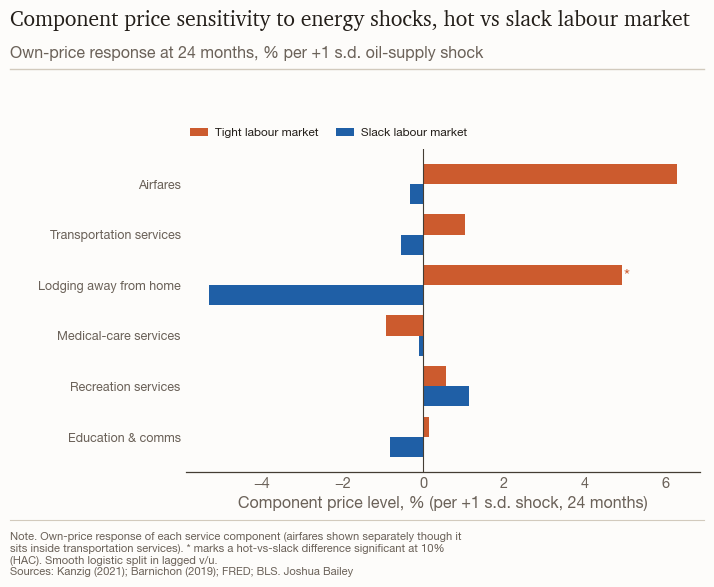

In [13]:
# ===== Component ATTRIBUTION: weighted contributions that reconcile to the supercore beta =====
# Independent component LPs are in each component's own price units and overlap (airfares is
# inside transportation services). To attribute the supercore passthrough we weight each
# NON-OVERLAPPING component's beta by its within-supercore expenditure share and close to the
# supercore beta with a residual:  beta_super(h) = sum_c (RIc/W_super) * beta_c(h) + residual.
w = pd.read_csv(CACHE/"cpi_weights.csv", index_col=0, parse_dates=True)
W_super = (w["iusxegm"] - w["ipcuhsho"] - w["ipcuhsrr"]).iloc[-1]
SHARE = {"Transportation services": w["ipcucst"].iloc[-1]/W_super,   # includes airfares
         "Lodging away from home":  w["ipcuhsro"].iloc[-1]/W_super,
         "Medical-care services":   w["ipcums"].iloc[-1]/W_super,
         "Recreation services":     w["irers"].iloc[-1]/W_super,
         "Education & comms":       w["irdecs"].iloc[-1]/W_super}
HBAR = 24
def _betas(lbl, h):
    s = sd_by_comp[lbl].set_index("h"); return s.betaH.get(h, np.nan), s.betaL.get(h, np.nan)
superH, superL = _betas("Supercore (total)", HBAR)
contrib = {}
for lbl, sh in SHARE.items():
    bH, bL = _betas(lbl, HBAR); contrib[lbl] = (sh*bH, sh*bL)
contrib["Other (residual)"] = (superH - sum(c[0] for c in contrib.values()),
                               superL - sum(c[1] for c in contrib.values()))
print(f"Attribution of the {HBAR}m supercore passthrough (pp), hot | slack  (shares of supercore in []):")
for lbl,(ch,cl) in contrib.items():
    sh = SHARE.get(lbl, 1-sum(SHARE.values()))
    print(f"  {lbl:24s} {ch:+.3f} | {cl:+.3f}   [{sh:.2f}]")
print(f"  {'= supercore total':24s} {superH:+.3f} | {superL:+.3f}")

# ---- Fig 2: signed stacked attribution (hot vs slack), bars sum to the supercore beta ----
order = ["Transportation services","Lodging away from home","Medical-care services",
         "Recreation services","Education & comms","Other (residual)"]
colmap = {"Transportation services": cs.ACCENT, "Medical-care services": cs.PRIMARY,
          "Lodging away from home": cs.TEAL, "Recreation services": cs.OCHRE,
          "Education & comms": cs.GREEN, "Other (residual)": cs.MUTE}
fig, ax = cs.figure(7.6, 6.4, rect=(0.055, 0.22, 0.90, 0.46))
for xi, key in [(0,0),(1,1)]:
    posb=negb=0.0
    for lbl in order:
        v = contrib[lbl][key]
        if not np.isfinite(v): continue
        base = posb if v>=0 else negb
        ax.bar(xi, v, bottom=base, width=0.5, color=colmap[lbl], edgecolor=cs.GROUND, lw=0.6,
               label=lbl if xi==0 else None)
        if v>=0: posb+=v
        else: negb+=v
    tot = superH if key==0 else superL
    ax.plot(xi, tot, "D", color=cs.SUMMARY, ms=8, zorder=6)
ax.plot([], [], "D", color=cs.SUMMARY, ms=8, label="Supercore (total)")
ax.axhline(0, color=cs.BASE, lw=0.8)
ax.set_xticks([0,1]); ax.set_xticklabels(["Tight labour market","Slack labour market"], fontsize=10)
ax.set_xlim(-0.6, 1.6)
_allv = [contrib[l][k] for l in order for k in (0,1) if np.isfinite(contrib[l][k])] + [superH, superL]
cs.floated_yaxis(ax, _yticks(np.array(_allv)))
cs.legend(ax, above=True)
note = ("Note. Each non-overlapping component's regime LP coefficient at 24 months weighted by its current "
        "within-supercore expenditure share; 'other' is the residual that closes to the supercore total "
        "(diamond). Components estimated on their own samples (recreation and education from 2010), so the "
        "split is approximate. Regimes from a smooth logistic split in lagged v/u, the basis on which "
        "the decomposition is cleanest.")
cs.title(fig, "The supercore passthrough is positive in tight markets, negative in slack",
         "Contribution to the 24-month supercore response, pp per +1 s.d. oil-supply shock")
cs.source(fig, note + "\n" + SRC_CPI)
cs.check_overlaps(fig, "fig2")
fig.savefig("cpi_supercore/fig2_component_attribution.png"); print("saved fig2 (attribution)")

# ---- Fig 2b: component PRICE sensitivity (own-units betas), incl. airfares ----
cm = comp_map.drop(index="Supercore (total)")
po = ["Airfares","Transportation services","Lodging away from home",
      "Medical-care services","Recreation services","Education & comms"]
cm = cm.loc[po]
fig, ax = cs.figure(7.8, 6.2, rect=(0.30, 0.20, 0.66, 0.52))
yv = np.arange(len(cm))[::-1]
ax.barh(yv+0.2, cm.hot_h24, height=0.4, color=cs.ACCENT, label="Tight labour market")
ax.barh(yv-0.2, cm.slack_h24, height=0.4, color=cs.PRIMARY, label="Slack labour market")
ax.axvline(0, color=cs.BASE, lw=0.8)
ax.set_yticks(yv); ax.set_yticklabels(cm.index, fontsize=9)
ax.spines["left"].set_visible(False); ax.tick_params(length=0)
ax.set_xlabel("Component price level, % (per +1 s.d. shock, 24 months)")
for yy, lbl in zip(yv, cm.index):
    if cm.loc[lbl,"wald_p_h24"] < 0.1:
        ax.text(max(cm.loc[lbl,"hot_h24"],0)+0.05, yy+0.2, "*", va="center", fontsize=12, color=cs.ACCENT)
cs.legend(ax, above=True)
note2 = ("Note. Own-price response of each service component (airfares shown separately though it sits inside "
         "transportation services). * marks a hot-vs-slack difference significant at 10% (HAC). Smooth logistic split in lagged v/u.")
cs.title(fig, "Component price sensitivity to energy shocks, hot vs slack labour market",
         "Own-price response at 24 months, % per +1 s.d. oil-supply shock")
cs.source(fig, note2 + "\n" + SRC_CPI)
cs.check_overlaps(fig, "fig2b")
fig.savefig("cpi_supercore/fig2b_price_sensitivity.png"); print("saved fig2b (price sensitivity)")


## Export + review

In [14]:
sd.to_csv("cpi_supercore/supercore_state_dependent_irf.csv", index=False)
comp_map.to_csv("cpi_supercore/component_passthrough_map.csv")
rob.to_csv("cpi_supercore/robustness_hot_slack_gap.csv")
lin.to_csv("cpi_supercore/supercore_linear_irf.csv", index=False)
print("CSVs written.")

st = sd_thr.set_index('h'); slog = sd.set_index('h')
print("\n=== HEADLINE READ (CPI supercore) ===")
print(f"Linear passthrough: supercore +{lin.set_index('h').beta[24]:.2f}pp at 24m per +1 s.d. (~{sd_oil_peak:.0f}% oil) shock.")
print(f"HEADLINE, hard v/u=1: hot +{st.betaH[24]:.2f}pp vs slack {st.betaL[24]:.2f}pp | "
      f"12m gap {st['diff'][12]:+.2f} (p={st.wald_p[12]:.3f}), 24m gap {st['diff'][24]:+.2f} (p={st.wald_p[24]:.3f}).")
print(f"Robustness, logistic split: 12m gap {slog['diff'][12]:+.2f} (p={slog.wald_p[12]:.3f}), "
      f"24m gap {slog['diff'][24]:+.2f} (p={slog.wald_p[24]:.3f}).")
print(f"Logistic, drop 2021-22: gap {rob.loc['v/u, drop 2021-22','diff_h24']:.2f}pp (p={rob.loc['v/u, drop 2021-22','wald_p']:.2f}).")
print(f"Logistic, u-gap long sample: gap {rob.loc['u-gap tightness, 1983+','diff_h24']:.2f}pp (p={rob.loc['u-gap tightness, 1983+','wald_p']:.2f}).")
print("Verdict: at the hard v/u=1 cut the supercore gap is suggestive but NOT significant at 24m (p~0.11);")
print("the smooth logistic split (robustness cross-check) is strongly significant (p~0.002). The two")
print("market-priced PCE gauges carry the significant headline result; see Sections P7-P8.")

CSVs written.

=== HEADLINE READ (CPI supercore) ===
Linear passthrough: supercore +0.07pp at 24m per +1 s.d. (~14% oil) shock.
HEADLINE, hard v/u=1: hot +0.59pp vs slack -0.02pp | 12m gap +0.18 (p=0.554), 24m gap +0.62 (p=0.115).
Robustness, logistic split: 12m gap +1.07 (p=0.030), 24m gap +2.05 (p=0.002).
Logistic, drop 2021-22: gap 1.65pp (p=0.03).
Logistic, u-gap long sample: gap 1.22pp (p=0.05).
Verdict: at the hard v/u=1 cut the supercore gap is suggestive but NOT significant at 24m (p~0.11);
the smooth logistic split (robustness cross-check) is strongly significant (p~0.002). The two
market-priced PCE gauges carry the significant headline result; see Sections P7-P8.


## Section P — replication for core PCE

PCE prices, monthly chain indices from **1959** (sample 1975–2025, including the 1970s oil shocks).
**Primary: core PCE** (`JCXFEBM`, all items ex food & energy) — the gauge the Fed targets. Headline
regime is the hard v/u = 1 split, with the logistic transition as robustness; same shock, lagged
long-v/u state, controls and inference. Outputs in `pce_core/`. (PCE core services ex housing,
`JCSXEHM`, is retained only as a robustness gauge in the grids/CSVs below, not charted.)

In [15]:
# --- P1. PCE data (public cache: BEA core PCE + core services ex housing) ---
pce = pd.read_csv(CACHE/"pce_core.csv", index_col=0, parse_dates=True)
df["ln_pce_super"] = (np.log(pce["jcsxehm"]) * 100).reindex(idx)   # PCE core services ex housing
df["ln_pce_core"] = (np.log(pce["jcxfebm"]) * 100).reindex(idx)    # core PCE
print("PCE supercore:", df.ln_pce_super.dropna().index.min().date(), "..",
      df.ln_pce_super.dropna().index.max().date(),
      "| estimation sample with shock+state: 1975-2025 (n~%d)" %
      df.dropna(subset=["ln_pce_super", "shock", "vu"]).shape[0])


PCE supercore: 1975-01-01 .. 2026-04-01 | estimation sample with shock+state: 1975-2025 (n~611)


In [16]:
# --- P2. PRIMARY gauge: core PCE (the Fed's gauge). v/u=1 headline, logistic robustness. ---
lin_pc = u.linear_pos_lp(df, "ln_pce_core", "shock", HORIZONS, state_raw="vu", n_lags=N_LAGS)
sd_pc_thr = u.state_sign_lp(df, "ln_pce_core", "shock", F_thr, HORIZONS, state_raw="vu", n_lags=N_LAGS)
sd_pc     = u.state_sign_lp(df, "ln_pce_core", "shock", F_vu, HORIZONS, state_raw="vu", n_lags=N_LAGS)
print("HEADLINE - core PCE (ex food & energy), hard v/u=1, 1975-2025:")
print(sd_pc_thr.set_index("h").loc[[6,12,18,24], ["betaH","betaL","diff","wald_p"]].round(3).to_string())
print("\nRobustness - core PCE, logistic split:")
print(sd_pc.set_index("h").loc[[6,12,18,24], ["betaH","betaL","diff","wald_p"]].round(3).to_string())
print("\nCore PCE: the tightness split is ~zero and insignificant under BOTH the hard v/u=1 cut "
      "(24m p=%.3f) and the logistic split (24m p=%.3f) - the administered-heavy headline gauge." % (
      sd_pc_thr.set_index("h").wald_p[24], sd_pc.set_index("h").wald_p[24]))
# regime_comparison.py owns fig1b_core_pce_state_dependent.png (v/u=1 + logistic) - not saved here.
sd_pc.to_csv("pce_core/core_pce_state_dependent_irf.csv", index=False)

# --- Robustness gauge: PCE core services ex housing (JCSXEHM). Retained for the robustness
#     grids/CSVs only; no dedicated chart (a separate gauge that needs too much explaining). ---
lin_p = u.linear_pos_lp(df, "ln_pce_super", "shock", HORIZONS, state_raw="vu", n_lags=N_LAGS)
sd_p_thr = u.state_sign_lp(df, "ln_pce_super", "shock", F_thr, HORIZONS, state_raw="vu", n_lags=N_LAGS)
sd_p     = u.state_sign_lp(df, "ln_pce_super", "shock", F_vu, HORIZONS, state_raw="vu", n_lags=N_LAGS)

HEADLINE - core PCE (ex food & energy), hard v/u=1, 1975-2025:
    betaH  betaL   diff  wald_p
h                              
6   0.008  0.112 -0.104   0.436
12  0.175  0.199 -0.024   0.880
18  0.305  0.304  0.001   0.996
24  0.175  0.477 -0.302   0.268

Robustness - core PCE, logistic split:
    betaH  betaL   diff  wald_p
h                              
6   0.074  0.087 -0.013   0.945
12  0.212  0.075  0.137   0.590
18  0.360  0.028  0.332   0.364
24  0.300  0.190  0.110   0.837

Core PCE: the tightness split is ~zero and insignificant under BOTH the hard v/u=1 cut (24m p=0.268) and the logistic split (24m p=0.837) - the administered-heavy headline gauge.


Continuous interaction (PCE supercore):
       b0     b1   p_b1     b2   p_b2  p_joint
h                                             
6   0.104 -0.053  0.304  0.036  0.116    0.291
12  0.172  0.007  0.936  0.045  0.301    0.396
24  0.167 -0.010  0.947  0.084  0.277    0.408
saved pce fig4


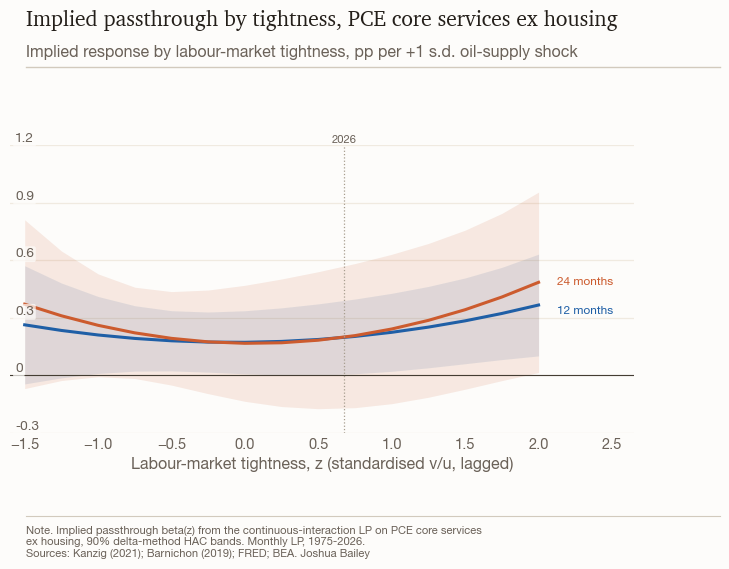

In [17]:
# --- P3. Functional form on PCE: continuous + quadratic interaction ---
ci_p = u.continuous_interaction_lp(df, "ln_pce_super", "shock", "vu", HORIZONS, quad=True, n_lags=N_LAGS)
cps = ci_p.set_index("h")
print("Continuous interaction (PCE supercore):")
print(cps.loc[[6,12,24], ["b0","b1","p_b1","b2","p_b2","p_joint"]].round(3).to_string())

zgrid = np.arange(-1.5, 2.01, 0.25)
zs_vu = df["vu"].dropna(); z26 = float((zs_vu.iloc[-1] - zs_vu.mean()) / zs_vu.std())
fig, ax = cs.figure(7.8, 6.0, rect=(0.055, 0.24, 0.80, 0.48))
series = [(12, cs.PRIMARY, "12 months"), (24, cs.ACCENT, "24 months")]
bands = []
for h, col, lbl in series:
    b = np.array([cps.loc[h, f"beta_at_{zg:+.2f}"] for zg in zgrid])
    s_ = np.array([cps.loc[h, f"se_at_{zg:+.2f}"] for zg in zgrid])
    ax.fill_between(zgrid, b - 1.645*s_, b + 1.645*s_, color=col, alpha=0.12, lw=0)
    ax.plot(zgrid, b, color=col, lw=2.2)
    bands += [b - 1.645*s_, b + 1.645*s_]
ax.axhline(0, color=cs.BASE, lw=0.8); ax.set_xlim(-1.6, 2.65)
cs.floated_yaxis(ax, _yticks(*bands))
ax.axvline(z26, color=cs.MUTE2, lw=0.9, ls=":")
ax.text(z26, ax.get_ylim()[1], "2026", ha="center", va="bottom", fontsize=8, color=cs.SUBTLE, family=cs.SANS)
ends = [(lbl, cps.loc[h, f"beta_at_{zgrid[-1]:+.2f}"], col) for h, col, lbl in series]
yy = cs.spread([e[1] for e in ends], 0.10 * (ax.get_ylim()[1] - ax.get_ylim()[0]))
for (lbl, _, col), y in zip(ends, yy):
    cs.direct_label(ax, zgrid[-1] + 0.05, y, lbl, col, size=8.5)
ax.set_xlabel("Labour-market tightness, z (standardised v/u, lagged)")
note_p4 = ("Note. Implied passthrough beta(z) from the continuous-interaction LP on PCE core services ex housing, "
           "90% delta-method HAC bands. Monthly LP, 1975-2026.")
cs.title(fig, "Implied passthrough by tightness, PCE core services ex housing",
         "Implied response by labour-market tightness, pp per +1 s.d. oil-supply shock")
cs.source(fig, note_p4 + "\n" + SRC_PCE)
cs.check_overlaps(fig, "fig4_pce")
fig.savefig("pce_core/fig4_pce_passthrough_curve.png"); print("saved pce fig4")
ci_p.to_csv("pce_core/continuous_interaction_irf_pce.csv", index=False)


In [18]:
# --- P4. PCE robustness: does the 1970s-inclusive sample fix the episode-fragility? ---
df_no2122_p = df.copy(); df_no2122_p.loc["2021-01-01":"2022-12-01", "shock"] = np.nan
df_pre_p = df.copy(); df_pre_p.loc["2020-01-01":, "shock"] = np.nan
df_8325 = df.loc["1983-01-01":]   # CPI-matched sample

def row_p(dd, F, sr, nl=N_LAGS):
    s = u.state_sign_lp(dd, "ln_pce_super", "shock", F, [24], state_raw=sr, n_lags=nl)
    return s["betaH"].iloc[0], s["betaL"].iloc[0], s["diff"].iloc[0], s["wald_p"].iloc[0]

specs_p = {
 "v/u, full 1975-2025":      (df, F_vu, "vu"),
 "v/u, drop 2021-22":        (df_no2122_p, F_vu, "vu"),
 "v/u, pre-2020":            (df_pre_p, F_vu, "vu"),
 "v/u, 1983+ (CPI-matched)": (df_8325, F_vu, "vu"),
 "v/u JOLTS only, 2001+":    (df, F_jolts, "vu_jolts"),
}
rob_p = pd.DataFrame([{ "spec": k, **dict(zip(["hot_h24","slack_h24","diff_h24","wald_p"], row_p(*v)))}
                      for k, v in specs_p.items()]).set_index("spec")
print("PCE supercore robustness at h=24:")
print(rob_p.round(3).to_string())
rob_p.to_csv("pce_core/robustness_pce.csv")

hr_p = u.asymmetry_lp(df, "ln_pce_super", "shock", [6,12,24], state="vu", size=True, n_lags=N_LAGS)
print("\nSize-vs-state horse-race (PCE):")
print(hr_p.set_index("h")[["b_size","p_size","b_state","p_state","p_sign_sym"]].round(3).to_string())
hr_p.to_csv("pce_core/horserace_pce.csv", index=False)
sd_p.to_csv("pce_core/pce_state_dependent_irf.csv", index=False)
lin_p.to_csv("pce_core/pce_linear_irf.csv", index=False)

PCE supercore robustness at h=24:
                          hot_h24  slack_h24  diff_h24  wald_p
spec                                                          
v/u, full 1975-2025        -0.292      0.615    -0.907   0.241
v/u, drop 2021-22          -0.701      0.885    -1.587   0.091
v/u, pre-2020              -1.033      1.135    -2.168   0.019
v/u, 1983+ (CPI-matched)    0.617      0.014     0.603   0.376
v/u JOLTS only, 2001+       0.996     -0.356     1.352   0.037

Size-vs-state horse-race (PCE):
    b_size  p_size  b_state  p_state  p_sign_sym
h                                               
6    0.156   0.016    0.004    0.897       0.776
12   0.155   0.110    0.070    0.240       0.687
24   0.307   0.017    0.108    0.241       0.100


In [19]:
# --- P5. Cross-measure comparison is regenerated with market-based core PCE as a
#         third gauge in Section P8. Here we just report the PCE check-measure read. ---
p24 = sd_p_thr.set_index("h").loc[24]          # PCE core services ex housing (1975+), hard v/u=1

print("=== PCE CHECK-MEASURE READ (core services ex housing) ===")
print(f"Hard v/u=1 (1975-2025): hot {p24.betaH:+.2f} vs slack {p24.betaL:+.2f}, gap {p24['diff']:.2f}pp (p={p24.wald_p:.3f})")
print(f"Logistic, drop 2021-22: gap {rob_p.loc['v/u, drop 2021-22','diff_h24']:.2f} (p={rob_p.loc['v/u, drop 2021-22','wald_p']:.3f}) | "
      f"pre-2020: {rob_p.loc['v/u, pre-2020','diff_h24']:.2f} (p={rob_p.loc['v/u, pre-2020','wald_p']:.3f})")

=== PCE CHECK-MEASURE READ (core services ex housing) ===
Hard v/u=1 (1975-2025): hot -0.03 vs slack +0.55, gap -0.59pp (p=0.110)
Logistic, drop 2021-22: gap -1.59 (p=0.091) | pre-2020: -2.17 (p=0.019)


## Section P7 — the cleanest market-priced aggregation (third spec)

If the channel lives in market-priced services, then *the more market-priced the measure, the cleaner the
result* — a falsifiable prediction. We test three steps up the "market-priced" ladder:
1. **Market-based core PCE** (`DPCXRG3M086SBEA`, FRED, monthly 1987+) — BEA's official measure, which
   strips out imputed/non-market prices (financial services furnished without payment, NPISH, insurance
   imputations). The recognised answer to "the maximalist market-priced basket." (It still values medical
   *care* at administered prices and includes core goods, so it is not maximal.)
2. **CPI supercore ex medical** — constructed by stripping medical out of the CPI supercore basket
   with time-varying shares; removes the administered-price chunk directly.
The prediction: gap rises monotonically core PCE → market-based core PCE → CPI supercore → CPI ex-medical.

In [20]:
# --- P7 data: market-based core PCE + CPI ex-medical basket (time-varying-share strip-out) ---
_mb = pd.read_csv(CACHE/"market_based_core_pce.csv", parse_dates=["date"]).set_index("date")
df["ln_mb_corepce"] = (np.log(_mb["mb_core_pce"]) * 100).reindex(idx)
_cw = pd.read_csv(CACHE/"cpi_weights.csv", index_col=0, parse_dates=True)
_s_med_c = (_cw["ipcums"] / (_cw["iusxegm"] - _cw["ipcuhsho"] - _cw["ipcuhsrr"])).reindex(idx).ffill()
_cpi_raw = pd.read_csv(CACHE/"cpi_components.csv", index_col=0, parse_dates=True)
def _strip_component(super_col, comp_price, share):
    """ex-component price level (ln x100) by removing one component from an aggregate (Tornqvist-style)."""
    g_super = df[super_col].diff()
    g_comp = (np.log(comp_price) * 100).reindex(idx).diff()
    g_ex = (g_super - share * g_comp) / (1.0 - share)
    return g_ex.fillna(0).cumsum()
df["ln_cpi_exmed"] = _strip_component("ln_pcuserh", _cpi_raw["pcums"], _s_med_c)
print("market-based core PCE: %s.. | medical share of CPI supercore (latest): %.0f%%" % (
    df.ln_mb_corepce.dropna().index.min().date(), 100*_s_med_c.iloc[-1]))


market-based core PCE: 1987-01-01.. | medical share of CPI supercore (latest): 25%


In [21]:
# --- P7a. Market-based core PCE (the MAIN gauge). v/u=1 headline, logistic robustness.
#     The hero state-dependent IRF is owned by regime_comparison.py; here we estimate the LPs
#     (they feed the fig9 ladder, the headline read and the CSV) without a duplicate chart. ---
lin_mb = u.linear_pos_lp(df.loc["1987":], "ln_mb_corepce", "shock", HORIZONS, state_raw="vu", n_lags=N_LAGS)
sd_mb_thr = u.state_sign_lp(df.loc["1987":], "ln_mb_corepce", "shock", F_thr, HORIZONS, state_raw="vu", n_lags=N_LAGS)
sd_mb     = u.state_sign_lp(df.loc["1987":], "ln_mb_corepce", "shock", F_vu, HORIZONS, state_raw="vu", n_lags=N_LAGS)
print("MAIN RESULT - market-based core PCE, hard v/u=1, 1987-2025:")
print(sd_mb_thr.set_index("h").loc[[6,12,18,24], ["betaH","betaL","diff","wald_p"]].round(3).to_string())
print("\nRobustness - market-based core PCE, logistic split:")
print(sd_mb.set_index("h").loc[[6,12,18,24], ["betaH","betaL","diff","wald_p"]].round(3).to_string())
sd_mb_thr.to_csv("pce_core/market_based_core_pce_irf.csv", index=False)

MAIN RESULT - market-based core PCE, hard v/u=1, 1987-2025:
    betaH  betaL   diff  wald_p
h                              
6   0.133  0.085  0.049   0.696
12  0.369  0.061  0.308   0.056
18  0.540 -0.001  0.541   0.055
24  0.719  0.008  0.711   0.047

Robustness - market-based core PCE, logistic split:
    betaH  betaL   diff  wald_p
h                              
6   0.231 -0.003  0.235   0.106
12  0.497 -0.168  0.665   0.005
18  0.703 -0.417  1.121   0.003
24  0.843 -0.511  1.354   0.006


In [22]:
# --- P7b. CPI supercore ex-medical: does removing administered medical raise the gap? ---
sd_cpi_xm = u.state_sign_lp(df.loc["1983":], "ln_cpi_exmed", "shock", F_vu, [12,24], state_raw="vu", n_lags=N_LAGS)
print("CPI supercore EX MEDICAL (market-priced services):")
print("  CPI:", sd_cpi_xm.set_index("h")[["diff","wald_p"]].round(3).to_dict("index"))
print("Read: removing administered medical prices RAISES the CPI supercore gap at 24m to %.2fpp — consistent "
      "with the channel concentrating in market-priced services." % sd_cpi_xm.set_index("h")["diff"][24])


CPI supercore EX MEDICAL (market-priced services):
  CPI: {12: {'diff': 1.386, 'wald_p': 0.007}, 24: {'diff': 2.781, 'wald_p': 0.001}}
Read: removing administered medical prices RAISES the CPI supercore gap at 24m to 2.78pp — consistent with the channel concentrating in market-priced services.


Market-price ladder, hot-slack gap at 12m (common 1987+ sample):
                 measure                           desc   gap     p
                Core PCE administered + imputed + goods 0.472 0.073
   Market-based core PCE         imputed prices removed 0.665 0.005
           CPI supercore       consumer-priced services 1.060 0.038
CPI supercore ex-medical + administered medical removed 1.349 0.013


saved fig9 (market-price ladder) to all folders


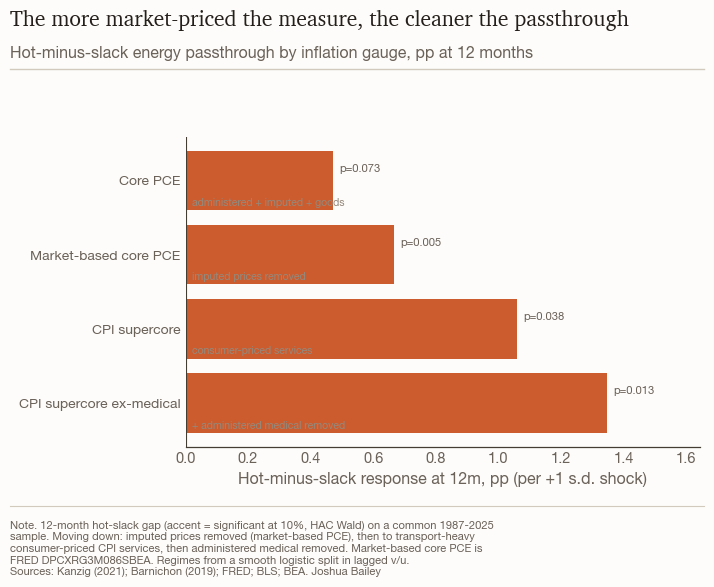

In [23]:
# --- P7c. Fig 9: the market-price ladder (common 1987+ sample) ---
ladder_specs = [
    ("Core PCE",                 "ln_pce_core",   "administered + imputed + goods"),
    ("Market-based core PCE",    "ln_mb_corepce", "imputed prices removed"),
    ("CPI supercore",            "ln_pcuserh",    "consumer-priced services"),
    ("CPI supercore ex-medical", "ln_cpi_exmed",  "+ administered medical removed"),
]
HL = 12
ladder = []
for name, col, desc in ladder_specs:
    r = u.state_sign_lp(df.loc["1987":], col, "shock", F_vu, [HL], state_raw="vu", n_lags=N_LAGS).iloc[0]
    ladder.append({"measure": name, "desc": desc, "gap": r["diff"], "p": r["wald_p"]})
ladder = pd.DataFrame(ladder)
print("Market-price ladder, hot-slack gap at %dm (common 1987+ sample):" % HL)
print(ladder.round(3).to_string(index=False))
ladder.to_csv("pce_core/market_price_ladder.csv", index=False)

fig, ax = cs.figure(7.8, 6.2, rect=(0.30, 0.24, 0.66, 0.50))
yv = np.arange(len(ladder))[::-1]
cols = [cs.ACCENT if p < 0.1 else cs.MUTE for p in ladder["p"]]
ax.barh(yv, ladder["gap"], color=cols)
ax.axvline(0, color=cs.BASE, lw=0.8)
for yy, v, p, d in zip(yv, ladder["gap"], ladder["p"], ladder["desc"]):
    ax.text(v + 0.02, yy + 0.16, f"p={p:.3f}", va="center", fontsize=8, color=cs.SUBTLE, family=cs.SANS)
    ax.text(0.02, yy - 0.30, d, va="center", fontsize=7.5, color=cs.FAINT, family=cs.SANS)
ax.set_yticks(yv); ax.set_yticklabels(ladder["measure"], fontsize=10)
ax.spines["left"].set_visible(False); ax.tick_params(length=0)
ax.set_xlim(0, ladder["gap"].max() * 1.22)
ax.set_xlabel("Hot-minus-slack response at 12m, pp (per +1 s.d. shock)")
note9 = ("Note. 12-month hot-slack gap (accent = significant at 10%, HAC Wald) on a common 1987-2025 sample. "
         "Moving down: imputed prices removed (market-based PCE), then to transport-heavy consumer-priced CPI "
         "services, then administered medical removed. Market-based core PCE is FRED DPCXRG3M086SBEA. Regimes from a smooth logistic split in lagged v/u.")
cs.title(fig, "The more market-priced the measure, the cleaner the passthrough",
         "Hot-minus-slack energy passthrough by inflation gauge, pp at 12 months")
cs.source(fig, note9 + "\n" + SRC_BOTH)
cs.check_overlaps(fig, "fig9")
for d in ["cpi_supercore", "pce_core", "pce_market_based"]:
    fig.savefig(f"{d}/fig9_market_price_ladder.png")
print("saved fig9 (market-price ladder) to all folders")


## Section P8 — market-based core PCE: a third headline measure

The third gauge: **BEA market-based core PCE** (`DPCXRG3M086SBEA`, FRED, PCE ex food & energy, monthly 1987+). "Market-based" strips out the imputed,
non-market prices in PCE — financial services furnished without payment (FISIM), the consumption of
non-profits, insurance imputations — leaving prices actually observed in market transactions. The headline market-based index (with food & energy) cannot be the dependent variable here, since energy is the shock; we use the ex-food-and-energy version. It is promoted from a within-PCE check
to a co-equal result alongside CPI supercore and core PCE, with its own folder `pce_market_based/`. The
state-dependent and linear LPs (`sd_mb`, `lin_mb`) were estimated in Section P7.

Market-based core PCE continuous interaction: b1 (linear-in-tightness) and b2 (convexity):
       b0     b1   p_b1     b2   p_b2  p_joint
h                                             
12  0.122  0.086  0.060  0.002  0.897    0.003
24  0.128  0.059  0.361  0.019  0.547    0.001


saved market-based fig4


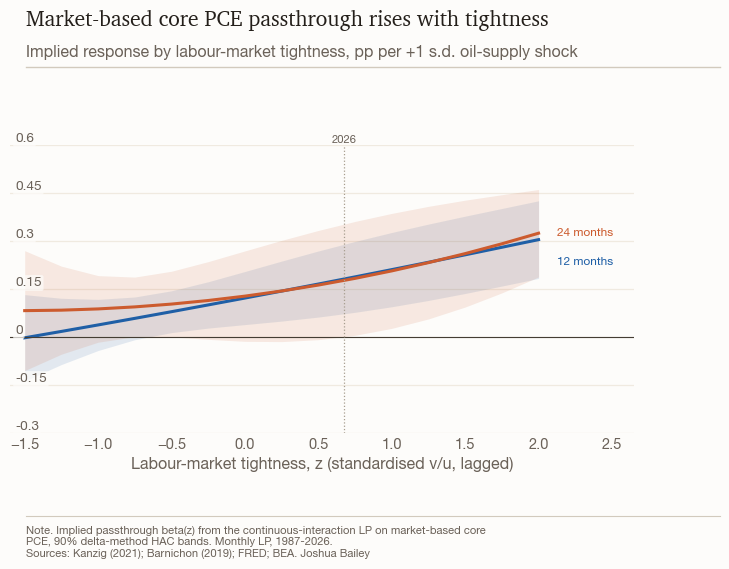

In [24]:
# --- P8a. Functional-form (continuous-interaction) curve for market-based core PCE ---
# The state-dependent IRF (fig1_market_based_state_dependent, v/u=1 + logistic) is owned by
# regime_comparison.py; sd_mb_thr / sd_mb were estimated in Section P7a.
Path("pce_market_based").mkdir(exist_ok=True)

# continuous-interaction passthrough curve beta(z)  [regime-agnostic]
ci_mb = u.continuous_interaction_lp(df.loc["1987":], "ln_mb_corepce", "shock", "vu", HORIZONS, quad=True, n_lags=N_LAGS)
cms = ci_mb.set_index("h")
print("Market-based core PCE continuous interaction: b1 (linear-in-tightness) and b2 (convexity):")
print(cms.loc[[12,24], ["b0","b1","p_b1","b2","p_b2","p_joint"]].round(3).to_string())
zgrid = np.arange(-1.5, 2.01, 0.25)
zs_vu = df["vu"].dropna(); z26 = float((zs_vu.iloc[-1] - zs_vu.mean()) / zs_vu.std())
fig, ax = cs.figure(7.8, 6.0, rect=(0.055, 0.24, 0.80, 0.48))
series = [(12, cs.PRIMARY, "12 months"), (24, cs.ACCENT, "24 months")]
bands = []
for h, col, lbl in series:
    b = np.array([cms.loc[h, f"beta_at_{zg:+.2f}"] for zg in zgrid])
    s_ = np.array([cms.loc[h, f"se_at_{zg:+.2f}"] for zg in zgrid])
    ax.fill_between(zgrid, b - 1.645*s_, b + 1.645*s_, color=col, alpha=0.12, lw=0)
    ax.plot(zgrid, b, color=col, lw=2.2)
    bands += [b - 1.645*s_, b + 1.645*s_]
ax.axhline(0, color=cs.BASE, lw=0.8); ax.set_xlim(-1.6, 2.65)
cs.floated_yaxis(ax, _yticks(*bands))
ax.axvline(z26, color=cs.MUTE2, lw=0.9, ls=":")
ax.text(z26, ax.get_ylim()[1], "2026", ha="center", va="bottom", fontsize=8, color=cs.SUBTLE, family=cs.SANS)
ends = [(lbl, cms.loc[h, f"beta_at_{zgrid[-1]:+.2f}"], col) for h, col, lbl in series]
yy = cs.spread([e[1] for e in ends], 0.10 * (ax.get_ylim()[1] - ax.get_ylim()[0]))
for (lbl, _, col), y in zip(ends, yy):
    cs.direct_label(ax, zgrid[-1] + 0.05, y, lbl, col, size=8.5)
ax.set_xlabel("Labour-market tightness, z (standardised v/u, lagged)")
note_mb4 = ("Note. Implied passthrough beta(z) from the continuous-interaction LP on market-based core PCE, 90% "
            "delta-method HAC bands. Monthly LP, 1987-2026.")
cs.title(fig, "Market-based core PCE passthrough rises with tightness",
         "Implied response by labour-market tightness, pp per +1 s.d. oil-supply shock")
cs.source(fig, note_mb4 + "\n" + SRC_PCE)
cs.check_overlaps(fig, "fig4_mb")
fig.savefig("pce_market_based/fig4_market_based_passthrough_curve.png"); print("saved market-based fig4")
ci_mb.to_csv("pce_market_based/continuous_interaction_irf.csv", index=False)

In [25]:
# --- P8b. Robustness + size/state horse-race for market-based core PCE ---
df_no2122_m = df.copy(); df_no2122_m.loc["2021-01-01":"2022-12-01", "shock"] = np.nan
df_pre_m = df.copy(); df_pre_m.loc["2020-01-01":, "shock"] = np.nan
def _row(dd, sr, F, nl=N_LAGS):
    r = u.state_sign_lp(dd.loc["1987":], "ln_mb_corepce", "shock", F, [12,24], state_raw=sr, n_lags=nl)
    g = r.set_index("h")
    return {"diff_h12": g["diff"][12], "p_h12": g.wald_p[12], "diff_h24": g["diff"][24], "p_h24": g.wald_p[24]}
rob_mb = pd.DataFrame({
    "v/u, full 1987-2025":   _row(df, "vu", F_vu),
    "v/u, drop 2021-22":     _row(df_no2122_m, "vu", F_vu),
    "v/u, pre-2020":         _row(df_pre_m, "vu", F_vu),
    "v/u, n_lags=12":        _row(df, "vu", F_vu, nl=12),
    "u-gap tightness":       _row(df, "ugap_tight", F_ug),
}).T
print("Market-based core PCE robustness (hot-slack gap):")
print(rob_mb.round(3).to_string())
rob_mb.to_csv("pce_market_based/robustness.csv")
hr_mb = u.asymmetry_lp(df.loc["1987":], "ln_mb_corepce", "shock", [6,12,24], state="vu", size=True, n_lags=N_LAGS)
print("\nSize-vs-state horse-race (market-based):")
print(hr_mb.set_index("h")[["b_size","p_size","b_state","p_state"]].round(3).to_string())
hr_mb.to_csv("pce_market_based/horserace.csv", index=False)

Market-based core PCE robustness (hot-slack gap):
                     diff_h12  p_h12  diff_h24  p_h24
v/u, full 1987-2025     0.665  0.005     1.354  0.006
v/u, drop 2021-22       0.381  0.150     1.109  0.041
v/u, pre-2020           0.407  0.195     0.887  0.131
v/u, n_lags=12          1.001  0.000     2.102  0.000
u-gap tightness         0.555  0.037     0.882  0.108

Size-vs-state horse-race (market-based):
    b_size  p_size  b_state  p_state
h                                   
6    0.017   0.532    0.044    0.012
12   0.039   0.457    0.111    0.001
24   0.120   0.116    0.139    0.003


In [26]:
# --- P8c. Market-based core PCE headline read (the MAIN result): v/u=1 vs logistic. ---
# The cross-gauge inflation-measure comparison is presented through the market-price ladder (fig9);
# the per-gauge v/u=1 hero IRFs are owned by regime_comparison.py. No duplicate bar chart here.
sm = sd_mb_thr.set_index('h'); smL = sd_mb.set_index('h'); m24 = sm.loc[24]
print("=== MARKET-BASED CORE PCE HEADLINE (the MAIN result) ===")
print(f"Hard v/u=1: hot {m24.betaH:+.2f} vs slack {m24.betaL:+.2f} at 24m; "
      f"12m gap {sm['diff'][12]:+.2f} (p={sm.wald_p[12]:.3f}), 24m gap {sm['diff'][24]:+.2f} (p={sm.wald_p[24]:.3f}).")
print(f"Robustness (logistic): 12m gap {smL['diff'][12]:+.2f} (p={smL.wald_p[12]:.3f}), "
      f"24m gap {smL['diff'][24]:+.2f} (p={smL.wald_p[24]:.3f}).")

=== MARKET-BASED CORE PCE HEADLINE (the MAIN result) ===
Hard v/u=1: hot +0.72 vs slack +0.01 at 24m; 12m gap +0.31 (p=0.056), 24m gap +0.71 (p=0.047).
Robustness (logistic): 12m gap +0.67 (p=0.005), 24m gap +1.35 (p=0.006).


## Section P9 — the 2026 paradigm question

The regime-sensitive robustness panels (fig3) and two-paradigms IRFs (fig11) for all three gauges, in both
the v/u=1 (main) and logistic (robustness) definitions, are generated by `regime_comparison.py`. Here we
the forward-looking question: the market is treating the current oil shock like 2021-22 and pricing Fed hikes;
but 2021-22 was a joint demand-and-supply overheating, whereas the current shock is a cleaner supply shock.
The **paradigm map** below shows where 2026 sits in tightness-vs-demand space relative to 2021-22.

In [27]:
# --- P9a. Robustness grid across tightness gauges and sample cuts (logistic basis), for the print.
#     The robustness PANEL charts (fig3) are drawn by regime_comparison.py in each measure folder. ---
df_no2122 = df.copy(); df_no2122.loc["2021-01-01":"2022-12-01", "shock"] = np.nan
df_pre = df.copy(); df_pre.loc["2020-01-01":, "shock"] = np.nan
ROB_SPECS = [
    ("v/u (Barnichon)",            df,         F_vu,    "vu",             N_LAGS),
    ("v/u, drop 2021-22",          df_no2122,  F_vu,    "vu",             N_LAGS),
    ("v/u, pre-2020",              df_pre,     F_vu,    "vu",             N_LAGS),
    ("v/u JOLTS only, 2001+",      df,         F_jolts, "vu_jolts",       N_LAGS),
    ("v/u, n_lags=12",             df,         F_vu,    "vu",             12),
    ("u-gap tightness",            df,         F_ug,    "ugap_tight",     N_LAGS),
    ("wage cyclical (vs trend)",   df,         F_wg,    "wage_cyc",       N_LAGS),
    ("demand-driven (Shapiro)",    df,         F_shap,  "shapiro_demand", N_LAGS),
    ("exp. de-anchoring (5y-10y)", df,         F_infl,  "exp_dev",        N_LAGS),
]
def run_robustness(y, start, h=24):
    rows = []
    for lbl, dd, F, sr, nl in ROB_SPECS:
        s = u.state_sign_lp(dd.loc[start:], y, "shock", F, [h], state_raw=sr, n_lags=nl).iloc[0]
        rows.append({"spec": lbl, "diff": s["diff"], "wald_p": s["wald_p"]})
    return pd.DataFrame(rows).set_index("spec")

rob_cpi_v = run_robustness("ln_pcuserh", "1983")
rob_pce_v = run_robustness("ln_pce_core", "1975")
rob_mb_v  = run_robustness("ln_mb_corepce", "1987")
print("Logistic robustness (gap @24m, p) - sign/significance across specs:")
for nm, rr in [("CPI supercore", rob_cpi_v), ("core PCE", rob_pce_v), ("market-based", rob_mb_v)]:
    sig = (rr.wald_p < 0.1).sum()
    print(f"  {nm:16s}: {sig}/9 specs significant; baseline gap {rr['diff'].iloc[0]:+.2f} (p={rr.wald_p.iloc[0]:.3f})")

Logistic robustness (gap @24m, p) - sign/significance across specs:
  CPI supercore   : 7/9 specs significant; baseline gap +2.05 (p=0.002)
  core PCE        : 2/9 specs significant; baseline gap +0.11 (p=0.837)
  market-based    : 5/9 specs significant; baseline gap +1.35 (p=0.006)


saved fig10 (paradigm map) to all three folders
2021-22 mean: v/u=1.54, demand=1.62 | now: v/u=0.95, demand=1.22 | 2015-19 demand=0.58


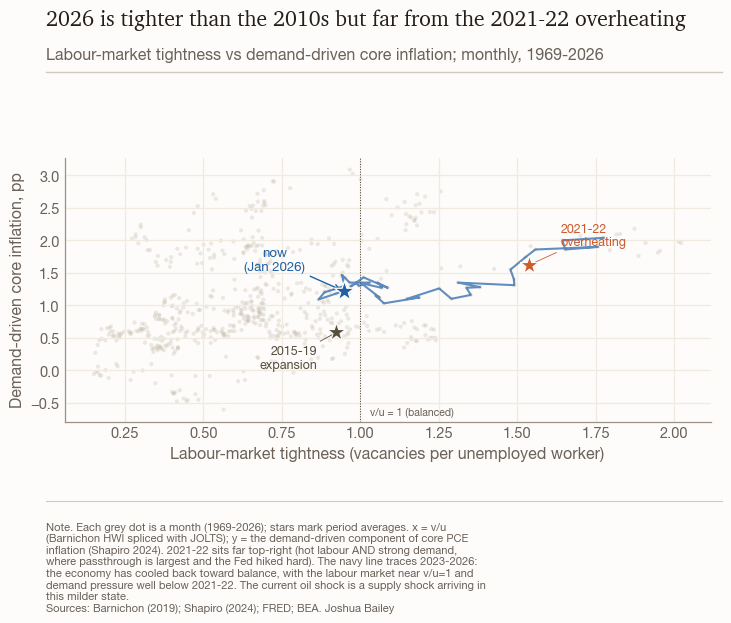

In [28]:
# --- P9b. Fig 10: the paradigm map — where 2026 sits vs 2021-22 ---
pm = pd.DataFrame({"vu": df["vu"], "dem": df["shapiro_demand"]}).dropna()
fig, ax = cs.figure(7.6, 6.6, rect=(0.10, 0.32, 0.85, 0.40))
cs.scatter_axes(ax)
ax.scatter(pm["vu"], pm["dem"], s=9, color=cs.MUTE, alpha=0.30, edgecolors="none", zorder=1)
traj = pm.loc["2023-01-01":]
ax.plot(traj["vu"], traj["dem"], color=cs.PRIMARY, lw=1.5, alpha=0.7, zorder=3)
def anchor(period, lab, color, dx, dy, ha="left"):
    seg = pm.loc[period[0]:period[1]]
    x, y = seg["vu"].mean(), seg["dem"].mean()
    ax.scatter([x], [y], s=190, color=color, marker="*", edgecolors=cs.GROUND, lw=0.8, zorder=6)
    ax.annotate(lab, (x, y), xytext=(x+dx, y+dy), fontsize=9, fontweight="bold", color=color, ha=ha,
                family=cs.SANS, arrowprops=dict(arrowstyle="-", color=color, lw=0.6))
anchor(("2021-01-01","2022-12-01"), "2021-22\noverheating", cs.ACCENT, 0.10, 0.30)
anchor(("2015-01-01","2019-12-01"), "2015-19\nexpansion", cs.SUMMARY, -0.06, -0.55, ha="right")
nowx, nowy = pm["vu"].iloc[-1], pm["dem"].iloc[-1]
ax.scatter([nowx], [nowy], s=230, color=cs.PRIMARY, marker="*", edgecolors=cs.GROUND, lw=0.9, zorder=7)
ax.annotate(f"now\n({pm.index[-1]:%b %Y})", (nowx, nowy), xytext=(nowx-0.22, nowy+0.32),
            fontsize=9.5, fontweight="bold", color=cs.PRIMARY, ha="center", family=cs.SANS,
            arrowprops=dict(arrowstyle="->", color=cs.PRIMARY, lw=1.0))
ax.axvline(1.0, color=cs.BASE, lw=0.7, ls=":")
ax.text(1.03, ax.get_ylim()[0]+0.1, "v/u = 1 (balanced)", fontsize=7.5, color=cs.SUBTLE, family=cs.SANS)
ax.set_xlabel("Labour-market tightness (vacancies per unemployed worker)")
ax.set_ylabel("Demand-driven core inflation, pp")
note10 = ("Note. Each grey dot is a month (1969-2026); stars mark period averages. x = v/u (Barnichon HWI spliced with "
          "JOLTS); y = the demand-driven component of core PCE inflation (Shapiro 2024). 2021-22 sits far top-right "
          "(hot labour AND strong demand, where passthrough is largest and the Fed hiked hard). The navy line traces "
          "2023-2026: the economy has cooled back toward balance, with the labour market near v/u=1 and demand "
          "pressure well below 2021-22. The current oil shock is a supply shock arriving in this milder state.")
cs.title(fig, "2026 is tighter than the 2010s but far from the 2021-22 overheating",
         "Labour-market tightness vs demand-driven core inflation; monthly, 1969-2026")
cs.source(fig, note10 + "\n" + SRC_MAP)
cs.check_overlaps(fig, "fig10")
for d in ["cpi_supercore", "pce_core", "pce_market_based"]:
    fig.savefig(f"{d}/fig10_paradigm_map.png")
print("saved fig10 (paradigm map) to all three folders")
print(f"2021-22 mean: v/u={pm.loc['2021':'2022','vu'].mean():.2f}, demand={pm.loc['2021':'2022','dem'].mean():.2f} | "
      f"now: v/u={nowx:.2f}, demand={nowy:.2f} | 2015-19 demand={pm.loc['2015':'2019','dem'].mean():.2f}")
